# JW $Z_4^{TF}$ system

Created: 01-09-2026

Objectives:
* Take states from [this notebook](../truncating_reduced_density_matrices/mps_optimisation_jw_z_4_tf_system.ipynb), and apply disentangling projectors to see if we get better (or the same) results.

# Imports

In [1]:
import numpy as np

In [2]:
import jax
jax.config.update('jax_platform_name', 'cpu')

import jax.numpy as jnp

In [3]:
import matplotlib.pyplot as plt

In [4]:
from tqdm import tqdm

In [5]:
from functools import reduce
from operator import mul

In [6]:
from random import random

In [7]:
import quimb.tensor as qtn
import quimb as qu

In [8]:
from scipy.stats import unitary_group

In [9]:
from collections import Counter

In [10]:
import pandas as pd

In [11]:
from time import time

In [12]:
from humanize import naturalsize

# Definitions
## Construct cluster state

In [13]:
np_up_X_state = 1/(np.sqrt(2))*np.array([1,1])

In [14]:
qu_up_X_state = qtn.Tensor(
    data=np_up_X_state,
    inds=('k',),
    tags='prod'
)

In [15]:
np_CZ = np.diag([1,1,1,-1])

In [16]:
np_CZ = np_CZ.reshape((2,)*4)

In [17]:
qu_CZ = qtn.Tensor(
    data=np_CZ,
    inds=('k1', 'k2', 'b1', 'b2'),
    tags='CZ'
)

In [18]:
np_hadamard = np.pow(2, -1/2)*np.array([
    [1,1],
    [1,-1]
])

In [19]:
qu_hadamard = qtn.Tensor(data=np_hadamard, inds=('k', 'b'), tags='Had')

In [20]:
def get_cluster_state_qu_tensor_network(num_sites):
    assert (num_sites%2) == 0

    product_state_tensors = [
        qu_up_X_state.reindex({'k': f'kc_1_{i}'})
        for i in range(num_sites)
    ]

    first_layer_circuit_tensors = [
        qu_CZ.reindex({
            'b1': f'kc_1_{i}',
            'b2': f'kc_1_{i+1}',
            'k1': f'kc_2_{i}',
            'k2': f'kc_2_{i+1}'
        })
        for i in range(0, num_sites, 2)
    ]


    second_layer_circuit_tensors = [
        qu_CZ.reindex({
            'b1': f'kc_2_{i}',
            'b2': f'kc_2_{(i+1)%num_sites}',
            'k1': f'kh_{i}',
            'k2': f'k{(i+1)%num_sites}'
        })
        for i in range(1, num_sites+1, 2)
    ]

    hadamard_layer = [
        qu_hadamard.reindex({
            'b': f'kh_{i}',
            'k': f'k{i}'
        })
        for i in range(1, num_sites, 2)
    ]
    all_tensors = (
        product_state_tensors
        + first_layer_circuit_tensors
        + second_layer_circuit_tensors
        + hadamard_layer
    )

    out = qtn.TensorNetwork(all_tensors, virtual=True)
    out.mangle_inner_()

    return out

## Construct product state

In [21]:
np_up_X_state = 1/(np.sqrt(2))*np.array([1,1])

In [22]:
np_up_Z_state = np.array([1,0])

In [23]:
qu_up_Z_state = qtn.Tensor(
    data=np_up_Z_state,
    inds=('k',),
    tags='prod'
)

In [24]:
alternating_states = [
    qu_up_X_state,
    qu_up_Z_state
]

def get_product_qu_tensor_network(num_sites):
    assert (num_sites%2) == 0

    product_state_tensors = [
        alternating_states[i%2].reindex({'k': f'k{i}'})
        for i in range(num_sites)
    ]

    out = qtn.TensorNetwork(
        product_state_tensors,
        virtual=True
    )
    out.mangle_inner_()

    return out

## Symmetries

In [25]:
def multikron(arrays):
    return reduce(np.kron, arrays)

In [26]:
np_I = np.array([
    [1,0],
    [0,1]
])

np_X = np.array([
    [0,1],
    [1,0]
])

np_Y = np.array([
    [0,-1j],
    [1j,0]
])

np_Z = np.array([
    [1,0],
    [0,-1]
])

In [27]:
qu_I = qtn.Tensor(
    np_I,
    inds=['k', 'b'],
    tags='X'
)

qu_X = qtn.Tensor(
    np_X,
    inds=['k', 'b'],
    tags='X'
)

qu_Y = qtn.Tensor(
    np_Y,
    inds=['k', 'b'],
    tags='Y'
)

qu_Z = qtn.Tensor(
    np_Z,
    inds=['k', 'b'],
    tags='Z'
)

In [28]:
def get_multisite_qu_X(num_sites):
    np_many_X = multikron([np_X]*num_sites)

    out = qtn.Tensor(
        np_many_X,
        inds=['k', 'b'],
        tags='mulit_site_X',
    )

    return out

In [29]:
def get_multisite_qu_I(num_sites):
    np_many_I = multikron([np_I]*num_sites)

    out = qtn.Tensor(
        np_many_I,
        inds=['k', 'b'],
        tags='mulit_site_I',
    )

    return out

In [30]:
qu_spin_fermion_fp = (
    qu_I.reindex({'k': 'ks', 'b': 'bs'})
    & qu_Z.reindex({'k': 'kf', 'b': 'bf'})
).contract()

qu_unit_cell_fp = qu_spin_fermion_fp.fuse({
    'k': ['ks', 'kf'],
    'b': ['bs', 'bf']
})

In [31]:
"""
def get_multisite_qu_fp(num_sites):
    assert (num_sites%2)==0

    num_unit_cells = (num_sites//2)

    np
"""

'\ndef get_multisite_qu_fp(num_sites):\n    assert (num_sites%2)==0\n\n    num_unit_cells = (num_sites//2)\n\n    np\n'

Decompose T symmetry as $MK$:

In [32]:
np_00 = np.array([[1,0], [0,0]])
np_11 = np.array([[0,0], [0,1]])

In [33]:
def tensor_product_operators(op_1, op_2):
    out = (
        op_1[..., np.newaxis, np.newaxis]
        *op_2[np.newaxis, np.newaxis, ...]
    )

    return out

In [34]:
np_M = (
    tensor_product_operators(np_X, np_00)
    + tensor_product_operators(np_Y, np_11)
)

In [35]:
qu_M = qtn.Tensor(
    np_M,
    inds=['ks', 'bs', 'kf', 'bf']
)

In [36]:
np_M_reindexed = (
    qu_M
    .fuse({
        'k': ['ks', 'kf'],
        'b': ['bs', 'bf']
    })
    .transpose('k', 'b')
    .data
)

## Extracting projectors

In [37]:
def random_uniform_complex(shape):
    return np.random.uniform(size=shape) + 1j*np.random.uniform(size=shape)

In [38]:
def lanczos_iteration(rho, v, sites):
    w = (
        rho & v.reindex({f'k{i}': f'b{i}' for i in sites})
    ).contract()

    w_norm = np.sqrt((w & w.conj()).contract())

    out = w/w_norm

    return out

In [39]:
def multiply_state_by_jw_string(state, sites):
    gates = [
        qu_Z.reindex({'k': f'k{i}', 'b': f'b{i}'})
        for i in sites if (i%2 == 1)
    ]

    out = qtn.TensorNetwork(
        [
            *gates,
            state.reindex({f'k{i}': f'b{i}' for i in sites if (i%2 == 1)})
        ]
    )

    return out.contract()

In [40]:
def lanczos_iteration_jw_even(rho, v, sites):
    w = multiply_state_by_jw_string(v, sites)
    w = (v+w)/2

    w = (
        rho & w.reindex({f'k{i}': f'b{i}' for i in sites})
    ).contract()

    w = (multiply_state_by_jw_string(w, sites) + w)/2
    w_norm = np.sqrt((w & w.conj()).contract())

    out = w/w_norm

    return out

In [41]:
def lanczos_algorithm(rho, v, sites, num_iters=20, jw_even=False):
    update_func = lanczos_iteration_jw_even if jw_even else lanczos_iteration
    for _ in range(num_iters):
        v = update_func(rho, v, sites)

    return v

In [42]:
def maximize_projector_states(rho, jw_even=False):
    k_inds = [i for i in rho.outer_inds() if i.startswith('k')]
    #b_inds = [i for i in rho.inds if i.startswith('b')]

    sites = [int(s[1:]) for s in k_inds]

    v = qtn.Tensor(
        data=random_uniform_complex((2,)*len(sites)),
        inds=[f'k{i}' for i in sites]
    )

    v = lanczos_algorithm(
        rho,
        v,
        sites,
        num_iters=20,
        jw_even=jw_even
    )

    new_v = lanczos_iteration(rho, v, sites)

    overlap = np.abs((v & new_v.conj()).contract())

    score = (
        v.reindex({f'k{i}': f'b{i}' for i in sites})
        & rho
        & v.conj()
    )
    score = score.contract()


    return score, v, overlap

In [43]:
def projector_state_check(state, rho, left_sites):
    left_right_rho = (
        rho
        & state
        & state.conj().reindex({s: f'b{s[1:]}' for s in state.inds})
    )

    left_right_rho = left_right_rho.contract()

    left_inds = [
        f'{s}{i}'
        for i in left_sites
        for s in 'kb'
    ]

    schmidt_decomp = qtn.tensor_core.tensor_split(
        left_right_rho,
        left_inds=left_inds,
        method='svd',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=False,
        bond_ind='v'
    )

    schmidt_vals = schmidt_decomp.tensors[1]

    return schmidt_vals

## Extract cut rho and EDM

In [44]:
def generate_edm_from_cut_state(cut_state, sites, num_defect_sites):
    # Lots of duplicate code, probably a better way to do this.
    assert 2*num_defect_sites < len(sites)
    assert (num_defect_sites%2) == 0
    assert (len(sites)%2) == 0
    assert (sites[0]%2) == 0

    left_defect_sites = sites[:num_defect_sites]
    right_defect_sites = sites[-num_defect_sites:]
    internal_sites = sites[num_defect_sites:-num_defect_sites]

    # Being sloppy with the gate indices as the symmetries are invariant
    # under transpose and conjugation.
    left_sym_gates = [
        qu_M.reindex({
            'ks': f'b{i}',
            'kf': f'b{i+1}',
            'bs': f'c{i}',
            'bf': f'c{i+1}'
        })
        for i in left_defect_sites[::2]
    ]

    inner_gates = [
        qu_M.reindex({
            'ks': f'k{i}',
            'kf': f'k{i+1}',
            'bs': f'b{i}',
            'bf': f'b{i+1}'
        })
        for i in internal_sites[::2]
    ]

    right_sym_gates = [
        qu_M.reindex({
            'ks': f'b{i}',
            'kf': f'b{i+1}',
            'bs': f'c{i}',
            'bf': f'c{i+1}'
        })
        for i in right_defect_sites[::2]
    ]

    reindex_map = (
        {
            f'k{i}': f'c{i}'
            for i in (left_defect_sites + right_defect_sites)
        }
        |
        {
            f'k{i}': f'b{i}'
            for i in internal_sites
        }
    )

    # The fact that we don't conjugate the reindexed cut_state means that
    # we are effectively implementing local complex conjugation.
    edm = (
        cut_state
        & cut_state.reindex(reindex_map)
        & left_sym_gates
        & inner_gates
        & right_sym_gates
    )

    edm = edm.contract()

    fuse_maps = [
        ('k_left', (f'k{i}' for i in left_defect_sites)),
        ('b_left', (f'b{i}' for i in left_defect_sites)),
        ('k_right', (f'k{i}' for i in right_defect_sites)),
        ('b_right', (f'b{i}' for i in right_defect_sites))
    ]

    edm.fuse(fuse_maps, inplace=True)

    return edm

## Defect operators

In [45]:
def random_uniform_complex(shape):
    return np.random.uniform(size=shape) + 1j*np.random.uniform(size=shape)

In [46]:
def solve_for_boundary_operators(edm, num_iters=100):
    # Careful, the indices are reversed here for ease.
    # i.e. the k, b indices have been swapped to make tensor contraction easier.
    scores = list()

    u_left = qtn.tensor_builder.rand_tensor(
        (edm.ind_size('b_left'), edm.ind_size('k_left')),
        inds=['k_left', 'b_left'],
        dtype='complex64'
    )

    u_right = qtn.tensor_builder.rand_tensor(
        (edm.ind_size('b_right'), edm.ind_size('k_right')),
        inds=['k_right', 'b_right'],
        dtype='complex64'
    )

    for _ in range(num_iters):
        right_edm = (edm & u_left).contract()
        data = right_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        u_right = qtn.Tensor(sol, inds = ['b_right', 'k_right'])

        left_edm = (edm & u_right).contract()
        data = left_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        u_left = qtn.Tensor(sol, inds = ['b_left', 'k_left'])

    return (u_left, u_right), scores

## Apply random unitary to groundstate

In [47]:
def generate_random_su2():
    # Randomly sample a unitary, and scale by the determinant.
    u = unitary_group.rvs(2)
    det_u = np.linalg.det(u)
    su = u*np.power(det_u, -0.5)

    return su

In [48]:
X =  generate_random_su2()

In [49]:
np.linalg.det(X)

np.complex128(1.0000000000000002-1.1102230246251568e-16j)

In [50]:
np.round(X @ (X.conj().T), 3)

array([[1.+0.j, 0.-0.j],
       [0.+0.j, 1.+0.j]])

In [51]:
def generate_random_symmetry_respecting_unitary_no_offset():
    # Generate a unitary which commutes with MK, where
    # M = X tensor (|0><0|) + Y tensor (|1><1|)

    phi = np.random.uniform(0, 2*np.pi)
    phi_phasor = np.exp(1j*phi)
    u0 = np.diag([phi_phasor, phi_phasor.conj()])

    if random() > 0.5:
        u0 = u0 @ np_X

    u1 = generate_random_su2()

    u = (
        tensor_product_operators(u0, np_00)
        + tensor_product_operators(u1, np_11)
    )

    qu_u = qtn.Tensor(
        u,
        inds=['ks', 'bs', 'kf', 'bf']
    )
    
    return qu_u

In [52]:
def generate_random_symmetry_respecting_unitary_offset():
    # Generate a unitary U such that IUI commutes with (MM)K, where
    # M = X tensor (|0><0|) + Y tensor (|1><1|), and concatenation denotes
    # tensor product.
    phi = np.random.uniform(0, 2*np.pi)
    phi_phasor = np.exp(1j*phi)
    u0 = np.diag([phi_phasor, phi_phasor.conj()])

    phi = np.random.uniform(0, 2*np.pi)
    phi_phasor = np.exp(1j*phi)
    u1 = np.diag([phi_phasor, phi_phasor.conj()])

    u = (
        tensor_product_operators(np_00, u0)
        + tensor_product_operators(np_11, u1)
    )

    qu_u = qtn.Tensor(
        u,
        inds=['kf', 'bf', 'ks', 'bs']
    )
    
    return qu_u

In [53]:
def generate_random_symmetry_respecting_unitary(offset):
    if offset:
        return generate_random_symmetry_respecting_unitary_offset()
    else:
        return generate_random_symmetry_respecting_unitary_no_offset()

In [54]:
# Warning, likely making assupmtions about shape of psi, number of sites being even here etc.
def apply_haar_random_fdlu_to_quimb_state(psi, domains_dict):
    num_sites = domains_dict['num_system_sites']

    depth = domains_dict['fdlu_depth']
    offset = domains_dict['fdlu_offset']
    all_circuit_lists = [
        list() for _ in range(depth)
    ]

    for layer, circuit_list in enumerate(all_circuit_lists):
        delta = layer
        is_offset = ((offset + delta)%2 == 1)

        for i in range(num_sites//2):
            site_1 = ((2*i)+delta+offset)%num_sites
            site_2 = ((2*i)+1+delta+offset)%num_sites

            u = generate_random_symmetry_respecting_unitary(is_offset)

            if is_offset:
                reindex_map = {
                    'kf': f'k_{layer+1}_{site_1}',
                    'ks': f'k_{layer+1}_{site_2}',
                    'bf': f'k_{layer}_{site_1}',
                    'bs': f'k_{layer}_{site_2}'
                }
            else:
                reindex_map = {
                    'ks': f'k_{layer+1}_{site_1}',
                    'kf': f'k_{layer+1}_{site_2}',
                    'bs': f'k_{layer}_{site_1}',
                    'bf': f'k_{layer}_{site_2}'
                }
            
            qu_u = u.reindex(reindex_map)

            circuit_list.append(qu_u)

    all_tensors = (
        [psi.reindex({f'k{i}': f'k_0_{i}' for i in range(num_sites)})]
        + sum(all_circuit_lists, start=[])
    )

    out = (
        qtn
        .TensorNetwork(all_tensors, virtual=False)
        .mangle_inner_()
        .reindex({f'k_{depth}_{i}': f'k{i}' for i in range(num_sites)}) 
    )

    return out

In [55]:
def extract_time_reversal_information_after_random_fdlu(psi, domains_dict,
    num_random_states=20):

    out = list()

    for _ in range(num_random_states):
        rand_psi = apply_haar_random_fdlu_to_quimb_state(psi, domains_dict)
        out.append(extract_time_reversal_information(rand_psi, domains_dict))

    return out

In [56]:
def extract_factorization_time_reversal_information_after_random_fdlu(psi,
    domains_dict, num_random_states=20):
    out = list()

    for _ in range(num_random_states):
        rand_psi = apply_haar_random_fdlu_to_quimb_state(psi, domains_dict)
        data = extract_factorization_time_reversal_information(
            rand_psi,
            domains_dict
        )
        out.append(data)

    return out

In [57]:
def get_quimb_psi_from_quspin_psi(quspin_psi):
    quimb_psi = qtn.Tensor(
        quspin_psi[::-1].reshape((2,)*num_sites),
        inds=[f'k{i}' for i in range(num_sites)]
    )

    return quimb_psi

## Sweep function

In [58]:
def extract_projector(psi, rho_sites, num_pad_sites, jw_even=False):
    rho = (psi & psi.conj().reindex({f'k{i}': f'b{i}' for i in rho_sites}))
    score, proj_vec, overlap = maximize_projector_states(rho, jw_even)

    larger_sites = list(range(
        min(rho_sites) - num_pad_sites,
        max(rho_sites)  + num_pad_sites
    ))

    larger_rho = (psi & psi.conj().reindex({f'k{i}': f'b{i}' for i in larger_sites}))

    # This is wrong, assumes that we're working with the left side.
    # So be careful of the right side schmidt_vals, likely wrong.
    schmidt_vals = projector_state_check(
        proj_vec,
        larger_rho,
        list(range(min(rho_sites) - num_pad_sites, min(rho_sites)))
    )

    return proj_vec, score, overlap, schmidt_vals

In [225]:
def find_invariants_via_projectors_from_random_state(psi, domains_dict, jw_even=False):
    rand_psi = apply_haar_random_fdlu_to_quimb_state(psi, domains_dict)

    left_proj_vec, *left_proj_vec_results = extract_projector(
        rand_psi,
        domains_dict['left_projector_sites'],
        domains_dict['num_projector_pad_sites'],
        jw_even
    )
    
    right_proj_vec, *right_proj_vec_results = extract_projector(
        rand_psi,
        domains_dict['right_projector_sites'],
        domains_dict['num_projector_pad_sites'],
        jw_even
    )
    
    cut_sites = list(range(
        min(domains_dict['left_projector_sites']),
        max(domains_dict['right_projector_sites'])+1
    ))
    
    cut_rho_unprojected = (
        rand_psi
        & rand_psi.conj().reindex({f'k{i}': f'b{i}' for i in cut_sites})
    )
    
    left_proj_sites = domains_dict['left_projector_sites']
    right_proj_sites = domains_dict['right_projector_sites']
    
    cut_rho = (
        cut_rho_unprojected.reindex({
            **{f'k{i}': f'l{i}' for i in left_proj_sites},
            **{f'k{i}': f'l{i}' for i in right_proj_sites},
            **{f'b{i}': f'c{i}' for i in left_proj_sites},
            **{f'b{i}': f'c{i}' for i in right_proj_sites}
        })
        & left_proj_vec.conj().reindex({f'k{i}': f'l{i}' for i in left_proj_sites})
        & left_proj_vec
        & left_proj_vec.reindex({f'k{i}': f'c{i}' for i in left_proj_sites})
        & left_proj_vec.conj().reindex({f'k{i}': f'b{i}' for i in left_proj_sites})
        & right_proj_vec.conj().reindex({f'k{i}': f'l{i}' for i in right_proj_sites})
        & right_proj_vec
        & right_proj_vec.reindex({f'k{i}': f'c{i}' for i in right_proj_sites})
        & right_proj_vec.conj().reindex({f'k{i}': f'b{i}' for i in right_proj_sites})
    )
    
    cut_rho_trace = (
        cut_rho
        .reindex({f'b{i}': f'k{i}' for i in cut_sites})
        .contract()
    )
    
    cut_rho = cut_rho/cut_rho_trace
    
    tranpose_map = (
        {f'k{i}': f'b{i}' for i in cut_sites}
        | {f'b{i}': f'k{i}' for i in cut_sites}
    )
    
    cut_rho_purity = (
        (cut_rho & cut_rho.reindex(tranpose_map))
        .contract()
    )
    
    sub_cut_sites = list(range(
        max(domains_dict['left_projector_sites'])+1,
        min(domains_dict['right_projector_sites'])
    ))
    
    sub_cut_rho = (
        cut_rho
        .reindex({f'k{i}': f'b{i}' for i in left_proj_sites + right_proj_sites})
    )
    
    sub_cut_rho_trace = (
        sub_cut_rho
        .reindex({f'b{i}': f'k{i}' for i in sub_cut_sites})
        .contract()
    )
    
    tranpose_map = (
        {f'k{i}': f'b{i}' for i in sub_cut_sites}
        | {f'b{i}': f'k{i}' for i in sub_cut_sites}
    )
    
    sub_cut_rho_purity = (
        (sub_cut_rho & sub_cut_rho.reindex(tranpose_map))
        .contract()
    )
    
    cut_score, cut_state, cut_overlap = maximize_projector_states(sub_cut_rho, jw_even)

    edm = generate_edm_from_cut_state(
        cut_state,
        sub_cut_sites,
        domains_dict['num_defect_sites']
    )

    defect_ops_results = solve_for_boundary_operators(
        edm,
        num_iters=20
    )

    left_defect_sites = list(range(
        max(domains_dict['left_projector_sites']) + 1,
        max(domains_dict['left_projector_sites']) + 1 + domains_dict['num_defect_sites']
    ))
    right_defect_sites = list(range(
        min(domains_dict['right_projector_sites']) - domains_dict['num_defect_sites'],
        min(domains_dict['right_projector_sites'])
    ))
    
    left_rdm = (
        cut_rho
        .reindex({
            f'b{i}': f'k{i}'
            for i in cut_sites if i not in left_defect_sites
        })
    )
    left_rdm = left_rdm.contract()
    left_fuse_map = [
        ('k_left', [f'k{i}' for i in left_defect_sites]),
        ('b_left', [f'b{i}' for i in left_defect_sites])
    ]
    left_rdm.fuse(left_fuse_map, inplace=True)
    
    right_rdm = (
        cut_rho
        .reindex({
            f'b{i}': f'k{i}'
            for i in cut_sites if i not in right_defect_sites
        })
    )
    right_rdm = right_rdm.contract()
    right_fuse_map = [
        ('k_right', [f'k{i}' for i in right_defect_sites]),
        ('b_right', [f'b{i}' for i in right_defect_sites])
    ]
    right_rdm.fuse(right_fuse_map, inplace=True)

    left_defect_op, right_defect_op = defect_ops_results[0]

    np_left_rdm = (
        left_rdm
        .transpose('k_left', 'b_left')
        .data
    )

    np_left_defect_op = (
        left_defect_op
        .transpose('k_left', 'b_left')
        .data
        .T
    )

    fp_list = [np_I, np_Z]
    np_fp = multikron([
        fp_list[i%2]
        for i in range(domains_dict['num_defect_sites'])
    ])

    left_defect_op_invariant = np.trace(
        np_fp
        @ np_left_defect_op.conj().T
        @ np_fp
        @ np_left_defect_op
        @ np_left_rdm
    )

    np_right_rdm = (
        right_rdm
        .transpose('k_right', 'b_right')
        .data
    )
    
    np_right_defect_op = (
        right_defect_op
        .transpose('k_right', 'b_right')
        .data
        .T
    )

    right_defect_op_invariant = np.trace(
        np_fp
        @ np_right_defect_op.conj().T
        @ np_fp
        @ np_right_defect_op
        @ np_right_rdm
    )

    out = {
        'left_proj_vec': left_proj_vec,
        'left_proj_vec_results': left_proj_vec_results,
        'right_proj_vec': right_proj_vec,
        'right_proj_vec_results': right_proj_vec_results,
        'cut_rho_purity': cut_rho_purity,
        'sub_cut_rho_trace': sub_cut_rho_trace,
        'sub_cut_rho_purity': sub_cut_rho_purity,
        'cut_score': cut_score,
        'cut_state': cut_state,
        'cut_overlap': cut_overlap,
        'defect_ops_scores': defect_ops_results[1],
        'left_defect_op': left_defect_op,
        'right_defect_op': right_defect_op,
        'left_defect_op_invariant': left_defect_op_invariant,
        'right_defect_op_invariant': right_defect_op_invariant
    }

    return out

# Check random unitaries and symmetry

In [60]:
domains_dict = {
    'num_system_sites': 32,
    'left_projector_sites': list(range(6, 10)),
    'right_projector_sites': list(range(22, 26)),
    'num_projector_pad_sites': 2,
    'num_defect_sites': 2,
    'fdlu_depth': 2,
    'fdlu_offset': 1
}

In [61]:
cluster_psi = get_cluster_state_qu_tensor_network(domains_dict['num_system_sites'])

In [62]:
rand_psi = apply_haar_random_fdlu_to_quimb_state(cluster_psi, domains_dict)

In [63]:
(rand_psi & rand_psi.conj()).contract()

np.complex128(0.9999999999999953-2.0816681711721685e-17j)

In [64]:
(rand_psi & cluster_psi.conj()).contract()

np.complex128(1.9558312968915725e-06-2.541098841762901e-21j)

In [65]:
symmetry_gates = [
    qu_M.reindex({
        'ks': f'k{i}', 'bs':f'b{i}',
        'kf': f'k{i+1}', 'bf':f'b{i+1}',
    })
    for i in range(0, domains_dict['num_system_sites'], 2)
]

In [66]:
sym_cluster_psi = qtn.TensorNetwork(
    [
        rand_psi.reindex({f'k{i}': f'b{i}' for i in range(domains_dict['num_system_sites'])}),
        *symmetry_gates
    ]
)

In [67]:
(
    sym_cluster_psi & sym_cluster_psi.conj()
).contract()

np.complex128(0.9999999999999951-6.938893903907228e-17j)

In [68]:
(
    sym_cluster_psi & rand_psi.conj()
).contract()

np.complex128(3.0332479776666956e-05-6.352747104407253e-20j)

In [69]:
(
    sym_cluster_psi & rand_psi
).contract()

np.complex128(0.9999999999999952-1.8735013540549517e-16j)

In [70]:
product_psi = get_product_qu_tensor_network(domains_dict['num_system_sites'])

In [71]:
rand_psi = apply_haar_random_fdlu_to_quimb_state(product_psi, domains_dict)

In [72]:
(rand_psi & rand_psi.conj()).contract()

np.complex128(0.999999999999997-8.326672684688674e-17j)

In [73]:
(rand_psi & product_psi.conj()).contract()

np.complex128(-5.227912124479583e-06+8.475298444068197e-21j)

In [74]:
symmetry_gates = [
    qu_M.reindex({
        'ks': f'k{i}', 'bs':f'b{i}',
        'kf': f'k{i+1}', 'bf':f'b{i+1}',
    })
    for i in range(0, domains_dict['num_system_sites'], 2)
]

In [75]:
sym_product_psi = qtn.TensorNetwork(
    [
        rand_psi.reindex({f'k{i}': f'b{i}' for i in range(domains_dict['num_system_sites'])}),
        *symmetry_gates
    ]
)

In [76]:
(
    sym_product_psi & sym_product_psi.conj()
).contract()

np.complex128(0.999999999999997-8.326672684688674e-17j)

In [77]:
(
    sym_product_psi & rand_psi.conj()
).contract()

np.complex128(0.0006640544091189081-3.5236570605778894e-19j)

In [78]:
(
    sym_product_psi & rand_psi
).contract()

np.complex128(0.999999999999997-8.326672684688674e-17j)

So random unitaries are symmetric, nice.

# Test - Cluster state

In [265]:
domains_dict = {
    'num_system_sites': 32,
    'left_projector_sites': list(range(6, 10)),
    'right_projector_sites': list(range(22, 26)),
    'num_projector_pad_sites': 2,
    'num_defect_sites': 2,
    'fdlu_depth': 0,
    'fdlu_offset': 0
}

In [266]:
cluster_psi = get_cluster_state_qu_tensor_network(domains_dict['num_system_sites'])

In [267]:
(cluster_psi & cluster_psi.conj()).contract()

np.float64(0.9999999999999964)

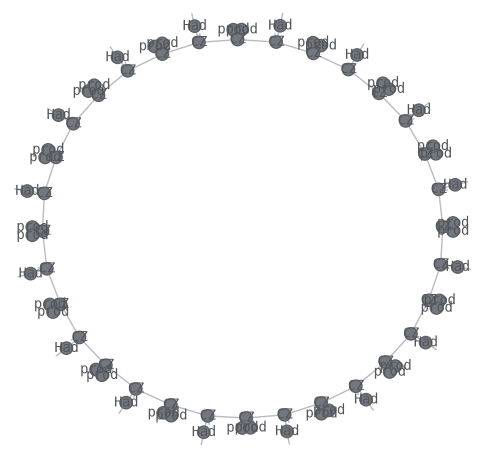

In [268]:
cluster_psi.draw()

In [282]:
results = list()

for _ in tqdm(range(20)):
    current = find_invariants_via_projectors_from_random_state(
        cluster_psi,
        domains_dict,
        jw_even=True
    )
    results.append(current)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:09<00:00,  2.19it/s]


### Analyze results

#### Projector scores

In [283]:
np.round(np.array([
    d['left_proj_vec_results'][0]
    for d in results
]), 3)

array([0.25-0.j, 0.25-0.j, 0.25-0.j, 0.25+0.j, 0.25-0.j, 0.25+0.j,
       0.25+0.j, 0.25+0.j, 0.25-0.j, 0.25+0.j, 0.25+0.j, 0.25+0.j,
       0.25+0.j, 0.25+0.j, 0.25-0.j, 0.25+0.j, 0.25+0.j, 0.25+0.j,
       0.25-0.j, 0.25-0.j])

In [284]:
np.round(np.array([
    d['right_proj_vec_results'][0]
    for d in results
]), 3)

array([0.25+0.j, 0.25+0.j, 0.25+0.j, 0.25+0.j, 0.25+0.j, 0.25-0.j,
       0.25-0.j, 0.25-0.j, 0.25+0.j, 0.25-0.j, 0.25-0.j, 0.25-0.j,
       0.25+0.j, 0.25-0.j, 0.25-0.j, 0.25-0.j, 0.25-0.j, 0.25-0.j,
       0.25+0.j, 0.25+0.j])

In [285]:
np.round(np.array([
    d['left_proj_vec_results'][1]
    for d in results
]), 3)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1.])

In [286]:
np.round(np.array([
    d['right_proj_vec_results'][1]
    for d in results
]), 3)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1.])

In [287]:
def get_schmidt_vals_ratio(schmidt_vals):
    if len(schmidt_vals.data) > 1:
        return schmidt_vals.data[1]/schmidt_vals.data[0]
    else:
        return 0

In [288]:
np.round(np.array([
    get_schmidt_vals_ratio(d['left_proj_vec_results'][2])
    for d in results
]), 3)

array([0.267, 0.267, 0.838, 0.513, 0.542, 0.799, 0.704, 0.527, 0.657,
       0.246, 0.22 , 0.214, 0.801, 0.774, 0.497, 0.299, 0.532, 0.29 ,
       0.508, 0.415])

In [289]:
np.round(np.array([
    get_schmidt_vals_ratio(d['right_proj_vec_results'][2])
    for d in results
]), 3)

array([0.591, 0.475, 0.974, 0.545, 0.285, 0.28 , 0.526, 0.52 , 0.995,
       0.868, 0.437, 0.53 , 0.786, 0.117, 0.237, 0.265, 0.3  , 0.126,
       0.407, 0.329])

#### Purities

In [290]:
np.round(np.array(
    [d['cut_rho_purity'] for d in results]
), 3)

array([0.356-0.j, 0.376-0.j, 0.252-0.j, 0.3  +0.j, 0.356-0.j, 0.333+0.j,
       0.282+0.j, 0.301+0.j, 0.261+0.j, 0.343+0.j, 0.406+0.j, 0.388-0.j,
       0.257+0.j, 0.413+0.j, 0.384+0.j, 0.432+0.j, 0.352+0.j, 0.522+0.j,
       0.326+0.j, 0.367+0.j])

In [291]:
np.round(np.array(
    [d['sub_cut_rho_trace'] for d in results]
), 3)

array([1.+0.j, 1.+0.j, 1.-0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j,
       1.+0.j, 1.+0.j, 1.+0.j, 1.-0.j, 1.+0.j, 1.-0.j, 1.+0.j, 1.-0.j,
       1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j])

In [292]:
np.round(np.array(
    [d['sub_cut_rho_purity'] for d in results]
), 3)

array([0.356-0.j, 0.376-0.j, 0.252-0.j, 0.3  +0.j, 0.356-0.j, 0.333+0.j,
       0.282+0.j, 0.301+0.j, 0.261+0.j, 0.343+0.j, 0.406+0.j, 0.388-0.j,
       0.257+0.j, 0.413+0.j, 0.384+0.j, 0.432+0.j, 0.352+0.j, 0.522+0.j,
       0.326+0.j, 0.367+0.j])

Purities are the same, which one could likely prove.

#### Cut state results

In [293]:
np.round(np.array(
    [d['cut_score'] for d in results]
), 3)

array([0.293+0.j, 0.254+0.j, 0.276-0.j, 0.428-0.j, 0.274-0.j, 0.434+0.j,
       0.385+0.j, 0.226-0.j, 0.301-0.j, 0.373+0.j, 0.25 +0.j, 0.538-0.j,
       0.248+0.j, 0.505+0.j, 0.268+0.j, 0.182-0.j, 0.267+0.j, 0.689+0.j,
       0.471-0.j, 0.532-0.j])

In [294]:
np.round(np.array(
    [d['cut_overlap'] for d in results]
), 3)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1.])

#### Defect op scores overlaps

In [295]:
np.round(np.array([d['defect_ops_scores'][-1] for d in results]), 5)

array([1.     , 1.     , 1.     , 1.     , 1.     , 1.     , 1.     ,
       0.99926, 1.     , 1.     , 1.     , 1.     , 0.9998 , 1.     ,
       1.     , 1.     , 1.     , 1.     , 1.     , 1.     ])

In [296]:
np.array([d['defect_ops_scores'][-1] for d in results])

array([1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 0.99926489, 1.        , 1.        ,
       1.        , 1.        , 0.99979591, 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ])

In [297]:
[d['defect_ops_scores'][-1] for d in results]

[np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0000000000000002),
 np.float64(0.9999999999999997),
 np.float64(1.0000000000000002),
 np.float64(0.9999999999999999),
 np.float64(1.0),
 np.float64(0.9992648911141773),
 np.float64(0.9999999999999998),
 np.float64(1.0),
 np.float64(0.9999999999999998),
 np.float64(1.0),
 np.float64(0.9997959095617838),
 np.float64(1.0000000000000004),
 np.float64(1.0),
 np.float64(1.0000000000000002),
 np.float64(0.9999999999999998),
 np.float64(1.0),
 np.float64(0.9999999999999998),
 np.float64(0.9999999999999998)]

#### Phases

In [298]:
left_phases = np.array([
    d['left_defect_op_invariant'] for d in results
])

In [299]:
left_phases.shape

(20,)

In [300]:
left_phases

array([-1.        +1.38777878e-17j, -1.        -1.24900090e-16j,
       -1.        +9.24446373e-33j, -1.        -2.77555756e-17j,
       -1.        -2.77555756e-17j, -0.99999486-2.76499836e-17j,
       -1.        -9.71445147e-17j, -0.97116256-3.71064302e-17j,
       -1.        -2.77555756e-17j, -0.71049034-1.16071176e-16j,
       -1.        -5.55111512e-17j, -0.64781358+5.56888370e-17j,
       -0.99582668-2.37023556e-18j, -0.99996972-2.77668787e-17j,
       -1.        +2.77555756e-17j, -1.        -2.77555756e-17j,
       -1.        -2.38621614e-32j, -0.55007819-9.71445147e-17j,
       -1.        -4.85722573e-17j, -0.41331005+1.11143928e-16j])

In [301]:
right_phases = np.array([
    d['right_defect_op_invariant'] for d in results
])

In [302]:
right_phases.shape

(20,)

In [303]:
right_phases

array([-1.        -2.02319911e-17j, -1.        +2.38410462e-17j,
       -1.        +1.98084616e-17j, -0.2948176 +1.05832051e-17j,
       -1.        -3.19844036e-17j, -1.        +6.50588393e-17j,
       -1.        -2.59318494e-17j, -0.96826559-2.84876931e-17j,
       -1.        -5.79883744e-17j, -1.        +2.52449517e-17j,
       -1.        +1.64183004e-17j, -0.90163807+8.40580690e-18j,
       -0.99501211+5.02807957e-17j, -1.        +9.33225667e-18j,
       -1.        -8.39177214e-18j, -1.        +3.40767742e-17j,
       -1.        -8.75652684e-17j, -1.        -9.05277180e-17j,
       -0.4217896 +1.82086161e-17j, -1.        +1.99031215e-17j])

## Analyze results

In [270]:
results['left_proj_vec_results']

[np.complex128(0.24999999999999917+6.938893903907207e-18j),
 np.float64(1.0),
 Tensor(shape=(2,), inds=('v',), tags=oset(['prod', 'CZ', 'Had', 'Z']))]

In [271]:
results['right_proj_vec_results']

[np.complex128(0.24999999999999917+1.7347234759768017e-18j),
 np.float64(1.0),
 Tensor(shape=(2,), inds=('v',), tags=oset(['prod', 'CZ', 'Had', 'Z']))]

In [272]:
results['left_proj_vec_results'][2].data

array([0.09702668, 0.07975002])

In [273]:
results['right_proj_vec_results'][2].data

array([0.12483033, 0.05194637])

In [274]:
results['cut_rho_purity']

np.complex128(0.29529034122841535+5.551115123125783e-17j)

Pretty good...

In [275]:
results['sub_cut_rho_trace']

np.complex128(0.9999999999999998+5.551115123125778e-17j)

In [276]:
results['sub_cut_rho_purity']

np.complex128(0.29529034122841535+5.551115123125783e-17j)

In [277]:
results['cut_score']

np.complex128(0.31856707631023407+8.326672684688048e-17j)

In [278]:
results['cut_overlap']

np.float64(0.9999999999998599)

In [279]:
results['defect_ops_scores'][-1]

np.float64(0.9999999999999998)

In [280]:
results['left_defect_op_invariant']

np.complex128(-1.0000000000000004-2.7755575615628944e-17j)

In [281]:
results['right_defect_op_invariant']

np.complex128(-0.9999999999999998-2.2328042256320877e-17j)

# Test - Random FDLU cluster state - depth 0

In [96]:
domains_dict = {
    'num_system_sites': 32,
    'left_projector_sites': list(range(6, 10)),
    'right_projector_sites': list(range(22, 26)),
    'num_projector_pad_sites': 2,
    'num_defect_sites': 2,
    'fdlu_depth': 0,
    'fdlu_offset': 0
}

In [97]:
cluster_psi = get_cluster_state_qu_tensor_network(domains_dict['num_system_sites'])

In [98]:
(cluster_psi & cluster_psi.conj()).contract()

np.float64(0.9999999999999964)

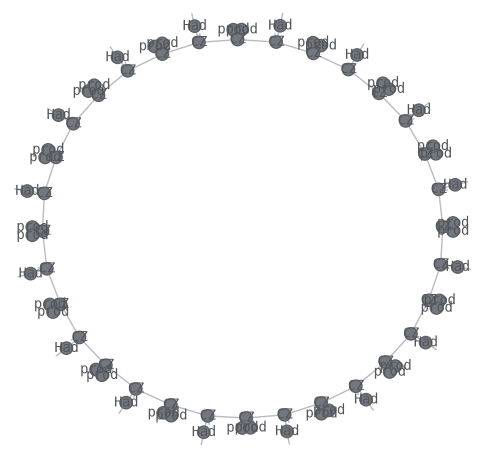

In [99]:
cluster_psi.draw()

In [100]:
rand_psi = apply_haar_random_fdlu_to_quimb_state(cluster_psi, domains_dict)

In [101]:
results = find_invariants_via_projectors_from_random_state(
    rand_psi,
    domains_dict,
    jw_even=True
)

## Analyze results

In [102]:
results['left_proj_vec_results']

[np.complex128(0.2499999999999991-2.6020852139652045e-18j),
 np.float64(1.0),
 Tensor(shape=(2,), inds=('v',), tags=oset(['prod', 'CZ', 'Had', 'Z']))]

In [103]:
results['right_proj_vec_results']

[np.complex128(0.24999999999999903-1.7347234759768017e-18j),
 np.float64(1.0),
 Tensor(shape=(2,), inds=('v',), tags=oset(['prod', 'CZ', 'Had', 'Z']))]

In [104]:
results['left_proj_vec_results'][2].data

array([0.10478314, 0.07199355])

In [105]:
results['right_proj_vec_results'][2].data

array([0.10738333, 0.06939337])

In [106]:
results['cut_rho_purity']

np.complex128(0.27054439482068393+1.3877787807814457e-17j)

Pretty good...

In [107]:
results['sub_cut_rho_trace']

np.complex128(1.0000000000000007+0j)

In [108]:
results['sub_cut_rho_purity']

np.complex128(0.27054439482068393+1.3877787807814457e-17j)

In [109]:
results['cut_score']

np.complex128(0.245602711867073+1.3877787807814472e-17j)

In [110]:
results['cut_overlap']

np.float64(0.9998087122203538)

In [111]:
results['defect_ops_scores'][-1]

np.float64(0.9999999999999989)

In [112]:
results['left_defect_op_invariant']

np.complex128(-0.9999999999999993-1.1102230053241504e-16j)

Not great...

In [113]:
results['right_defect_op_invariant']

np.complex128(-0.9999999999999958-1.966668984480959e-17j)

# Test - Random FDLU cluster state - depth 1

In [114]:
domains_dict = {
    'num_system_sites': 32,
    'left_projector_sites': list(range(4, 10)),
    'right_projector_sites': list(range(22, 28)),
    'num_projector_pad_sites': 2,
    'num_defect_sites': 2,
    'fdlu_depth': 1,
    'fdlu_offset': 0
}

In [115]:
cluster_psi = get_cluster_state_qu_tensor_network(domains_dict['num_system_sites'])

In [116]:
(cluster_psi & cluster_psi.conj()).contract()

np.float64(0.9999999999999964)

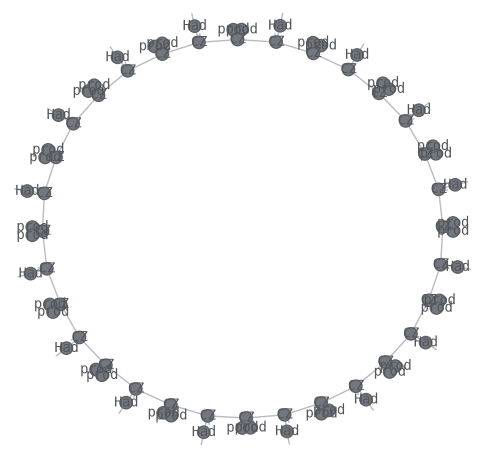

In [117]:
cluster_psi.draw()

In [118]:
rand_psi = apply_haar_random_fdlu_to_quimb_state(cluster_psi, domains_dict)

In [119]:
results = find_invariants_via_projectors_from_random_state(
    rand_psi,
    domains_dict,
    jw_even=True
)

## Analyze results

In [120]:
results['left_proj_vec_results']

[np.complex128(0.249999999999999-1.7043806315262112e-17j),
 np.float64(1.0),
 Tensor(shape=(2,), inds=('v',), tags=oset(['prod', 'CZ', 'Had', 'Z']))]

In [121]:
results['right_proj_vec_results']

[np.complex128(0.24999999999999928-1.9804010580945023e-17j),
 np.float64(1.0),
 Tensor(shape=(2,), inds=('v',), tags=oset(['prod', 'CZ', 'Had', 'Z']))]

In [122]:
results['left_proj_vec_results'][2].data

array([0.0012851 , 0.00014182])

In [123]:
results['right_proj_vec_results'][2].data

array([0.02188079, 0.00834065])

In [124]:
results['cut_rho_purity']

np.complex128(0.45940039611283223+1.2062368767170418e-17j)

Pretty good...

In [125]:
results['sub_cut_rho_trace']

np.complex128(1.0000000000000002+0j)

In [126]:
results['sub_cut_rho_purity']

np.complex128(0.45940039611283223+1.2062368767170418e-17j)

In [127]:
results['cut_score']

np.complex128(0.2436822865159306+1.7906955098843563e-17j)

In [128]:
results['cut_overlap']

np.float64(1.0000000000000002)

In [129]:
results['defect_ops_scores'][-1]

np.float64(1.0)

In [130]:
results['left_defect_op_invariant']

np.complex128(-0.8483388139357373-2.668051762987615e-17j)

Not great...

In [131]:
results['right_defect_op_invariant']

np.complex128(-0.6711684618453437+3.8119015654013567e-17j)

# Test - Random FDLU cluster state - depth 2

In [132]:
domains_dict = {
    'num_system_sites': 32,
    'left_projector_sites': list(range(4, 10)),
    'right_projector_sites': list(range(22, 28)),
    'num_projector_pad_sites': 2,
    'num_defect_sites': 2,
    'fdlu_depth': 2,
    'fdlu_offset': 0
}

In [133]:
cluster_psi = get_cluster_state_qu_tensor_network(domains_dict['num_system_sites'])

In [134]:
(cluster_psi & cluster_psi.conj()).contract()

np.float64(0.9999999999999964)

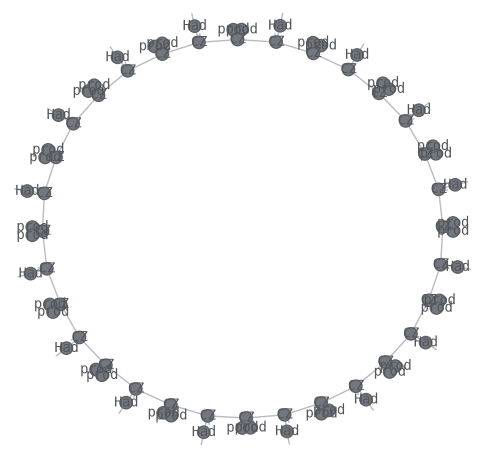

In [135]:
cluster_psi.draw()

In [136]:
rand_psi = apply_haar_random_fdlu_to_quimb_state(cluster_psi, domains_dict)

In [137]:
results = find_invariants_via_projectors_from_random_state(
    rand_psi,
    domains_dict,
    jw_even=True
)

## Analyze results

In [138]:
results['left_proj_vec_results']

[np.complex128(0.21122050629422923+6.071532165918825e-18j),
 np.float64(0.9999999999999999),
 Tensor(shape=(3,), inds=('v',), tags=oset(['prod', 'CZ', 'Had', 'Z']))]

In [139]:
results['right_proj_vec_results']

[np.complex128(0.2136893019498784-5.149960319306146e-18j),
 np.float64(0.9999999999999999),
 Tensor(shape=(3,), inds=('v',), tags=oset(['prod', 'CZ', 'Had', 'Z']))]

In [140]:
results['left_proj_vec_results'][2].data

array([0.03384656, 0.00992536, 0.00127368])

In [141]:
results['right_proj_vec_results'][2].data

array([0.00416601, 0.00163551, 0.00035471])

In [142]:
results['cut_rho_purity']

np.complex128(0.31005442006646033-2.6020852139652106e-18j)

Pretty good...

In [143]:
results['sub_cut_rho_trace']

np.complex128(1.0000000000000002+1.214306433183765e-17j)

In [144]:
results['sub_cut_rho_purity']

np.complex128(0.31005442006646033-2.6020852139652106e-18j)

In [145]:
results['cut_score']

np.complex128(0.4460589295172883+2.2079425200240392e-17j)

In [146]:
results['cut_overlap']

np.float64(1.0000000000000002)

In [147]:
results['defect_ops_scores'][-1]

np.float64(0.6844199588428197)

In [148]:
results['left_defect_op_invariant']

np.complex128(-0.30645143278184184+5.637851678318317e-18j)

In [149]:
results['right_defect_op_invariant']

np.complex128(-0.34708702314114087-7.979727989493313e-17j)

# Test - Random FDLU product state

In [150]:
domains_dict = {
    'num_system_sites': 32,
    'left_projector_sites': list(range(6, 10)),
    'right_projector_sites': list(range(22, 26)),
    'num_projector_pad_sites': 2,
    'num_defect_sites': 2,
    'fdlu_depth': 2,
    'fdlu_offset': 0
}

In [151]:
product_psi = get_product_qu_tensor_network(domains_dict['num_system_sites'])

In [152]:
(product_psi & product_psi.conj()).contract()

np.float64(0.9999999999999964)

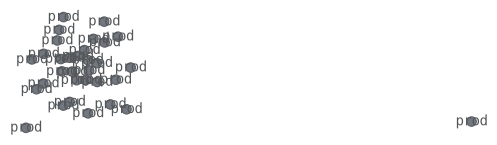

In [153]:
product_psi.draw()

In [154]:
rand_psi = apply_haar_random_fdlu_to_quimb_state(product_psi, domains_dict)

In [155]:
results = find_invariants_via_projectors_from_random_state(
    rand_psi,
    domains_dict,
    jw_even=True
)

## Analyze results

In [156]:
results['left_proj_vec_results']

[np.complex128(0.9999999999999973-3.3213180212829904e-17j),
 np.float64(1.0000000000000002),
 Tensor(shape=(1,), inds=('v',), tags=oset(['prod', 'Z']))]

In [157]:
results['right_proj_vec_results']

[np.complex128(0.9999999999999974-4.163336342344337e-17j),
 np.float64(1.0),
 Tensor(shape=(1,), inds=('v',), tags=oset(['prod', 'Z']))]

In [158]:
results['left_proj_vec_results'][2].data

array([0.9708812])

In [159]:
results['right_proj_vec_results'][2].data

array([0.00085804])

In [160]:
results['cut_rho_purity']

np.complex128(0.9999999999999996-6.418476861114186e-17j)

Pretty good...

In [161]:
results['sub_cut_rho_trace']

np.complex128(0.9999999999999998-7.820082866141258e-17j)

In [162]:
results['sub_cut_rho_purity']

np.complex128(0.9999999999999996-6.418476861114186e-17j)

In [163]:
results['cut_score']

np.complex128(0.9999999999999993+0j)

In [164]:
results['cut_overlap']

np.float64(1.0000000000000002)

In [165]:
results['defect_ops_scores'][-1]

np.float64(1.0000000000000002)

In [166]:
results['left_defect_op_invariant']

np.complex128(0.9999999999999993+0j)

Not great...

In [167]:
results['right_defect_op_invariant']

np.complex128(0.9999999999999996+2.0599841277224646e-18j)

Working great on product state.

# Sweep
## Product state

In [168]:
domains_dict = {
    'num_system_sites': 32,
    'left_projector_sites': list(range(6, 10)),
    'right_projector_sites': list(range(22, 26)),
    'num_projector_pad_sites': 2,
    'num_defect_sites': 2,
    'fdlu_depth': 2,
    'fdlu_offset': 0
}

In [169]:
product_psi = get_product_qu_tensor_network(domains_dict['num_system_sites'])

In [170]:
results = list()

for _ in tqdm(range(20)):
    current = find_invariants_via_projectors_from_random_state(product_psi, domains_dict)
    results.append(current)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:05<00:00,  3.42it/s]


### Analyze results

#### Projector scores

In [171]:
np.round(np.array([
    d['left_proj_vec_results'][0]
    for d in results
]), 3)

array([1.+0.j, 1.-0.j, 1.+0.j, 1.+0.j, 1.-0.j, 1.+0.j, 1.+0.j, 1.-0.j,
       1.+0.j, 1.-0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.-0.j, 1.+0.j, 1.+0.j,
       1.-0.j, 1.+0.j, 1.+0.j, 1.+0.j])

In [172]:
np.round(np.array([
    d['right_proj_vec_results'][0]
    for d in results
]), 3)

array([1.+0.j, 1.+0.j, 1.+0.j, 1.-0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.-0.j,
       1.+0.j, 1.+0.j, 1.+0.j, 1.-0.j, 1.-0.j, 1.+0.j, 1.-0.j, 1.-0.j,
       1.-0.j, 1.+0.j, 1.-0.j, 1.-0.j])

In [173]:
np.round(np.array([
    d['left_proj_vec_results'][1]
    for d in results
]), 3)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1.])

In [174]:
np.round(np.array([
    d['right_proj_vec_results'][1]
    for d in results
]), 3)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1.])

In [175]:
def get_schmidt_vals_ratio(schmidt_vals):
    if len(schmidt_vals.data) > 1:
        return schmidt_vals.data[1]/schmidt_vals.data[0]
    else:
        return 0

In [176]:
np.round(np.array([
    get_schmidt_vals_ratio(d['left_proj_vec_results'][2])
    for d in results
]), 3)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [177]:
np.round(np.array([
    get_schmidt_vals_ratio(d['right_proj_vec_results'][2])
    for d in results
]), 3)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

#### Purities

In [178]:
np.round(np.array(
    [d['cut_rho_purity'] for d in results]
), 3)

array([1.-0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j,
       1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.-0.j, 1.-0.j, 1.-0.j, 1.+0.j,
       1.+0.j, 1.+0.j, 1.+0.j, 1.-0.j])

In [179]:
np.round(np.array(
    [d['sub_cut_rho_trace'] for d in results]
), 3)

array([1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.-0.j,
       1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.-0.j, 1.+0.j, 1.-0.j, 1.-0.j,
       1.+0.j, 1.+0.j, 1.-0.j, 1.-0.j])

In [180]:
np.round(np.array(
    [d['sub_cut_rho_purity'] for d in results]
), 3)

array([1.-0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j,
       1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.-0.j, 1.-0.j, 1.-0.j, 1.+0.j,
       1.+0.j, 1.+0.j, 1.+0.j, 1.-0.j])

Purities are the same, which one could likely prove.

#### Cut state results

In [181]:
np.round(np.array(
    [d['cut_score'] for d in results]
), 3)

array([1.-0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j,
       1.+0.j, 1.+0.j, 1.-0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.-0.j, 1.+0.j,
       1.-0.j, 1.+0.j, 1.+0.j, 1.-0.j])

In [182]:
np.round(np.array(
    [d['cut_overlap'] for d in results]
), 3)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1.])

#### Defect op scores overlaps

In [183]:
np.round(np.array([d['defect_ops_scores'][-1] for d in results]), 5)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1.])

In [184]:
np.array([d['defect_ops_scores'][-1] for d in results])

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1.])

In [185]:
[d['defect_ops_scores'][-1] for d in results]

[np.float64(1.0000000000000004),
 np.float64(1.0000000000000002),
 np.float64(1.0000000000000002),
 np.float64(1.0000000000000004),
 np.float64(0.9999999999999998),
 np.float64(1.0000000000000002),
 np.float64(0.9999999999999998),
 np.float64(1.0000000000000004),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0000000000000009),
 np.float64(1.0),
 np.float64(1.0000000000000002),
 np.float64(0.9999999999999999),
 np.float64(1.0000000000000002),
 np.float64(0.9999999999999997),
 np.float64(0.9999999999999997),
 np.float64(1.0000000000000002),
 np.float64(1.0000000000000002),
 np.float64(1.0000000000000007)]

#### Phases

In [186]:
left_phases = np.array([
    d['left_defect_op_invariant'] for d in results
])

In [187]:
left_phases.shape

(20,)

In [188]:
left_phases

array([1.+7.09068221e-17j, 1.+1.04083409e-17j, 1.+6.24500451e-17j,
       1.-2.77555756e-17j, 1.+9.02056208e-17j, 1.+2.77555756e-17j,
       1.+9.71445147e-17j, 1.-5.55111512e-17j, 1.-8.32667268e-17j,
       1.+7.97972799e-17j, 1.+1.11022302e-16j, 1.+1.38777878e-17j,
       1.-1.66533454e-16j, 1.-3.29597460e-17j, 1.-1.38777878e-16j,
       1.+7.80625564e-17j, 1.-1.12757026e-17j, 1.-5.55111512e-17j,
       1.-2.77555756e-17j, 1.-2.08166817e-16j])

In [189]:
right_phases = np.array([
    d['right_defect_op_invariant'] for d in results
])

In [190]:
right_phases.shape

(20,)

In [191]:
right_phases

array([1.-1.38777878e-17j, 1.+8.67361738e-18j, 1.+1.80411242e-16j,
       1.+6.93889390e-18j, 1.+0.00000000e+00j, 1.+0.00000000e+00j,
       1.-1.23259516e-32j, 1.-5.89805982e-17j, 1.-2.94902991e-17j,
       1.+6.93889390e-17j, 1.+4.62223187e-33j, 1.+0.00000000e+00j,
       1.+2.46519033e-32j, 1.-1.73472348e-17j, 1.-1.35308431e-16j,
       1.-1.21430643e-17j, 1.-1.38777878e-17j, 1.+4.85722573e-17j,
       1.-4.16333634e-17j, 1.-1.76291273e-16j])

## Cluster state

In [217]:
domains_dict = {
    'num_system_sites': 32,
    'left_projector_sites': list(range(4, 10)),
    'right_projector_sites': list(range(22, 28)),
    'num_projector_pad_sites': 2,
    'num_defect_sites': 4,
    'fdlu_depth': 2,
    'fdlu_offset': 0
}

In [218]:
cluster_psi = get_cluster_state_qu_tensor_network(domains_dict['num_system_sites'])

In [226]:
results = list()

for _ in tqdm(range(20)):
    current = find_invariants_via_projectors_from_random_state(cluster_psi, domains_dict)
    results.append(current)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:12<00:00,  1.62it/s]


### Analyze results

#### Projector scores

In [227]:
np.round(np.array([
    d['left_proj_vec_results'][0]
    for d in results
]), 3)

array([0.178-0.j, 0.233+0.j, 0.155+0.j, 0.159-0.j, 0.223-0.j, 0.125+0.j,
       0.245+0.j, 0.145+0.j, 0.236+0.j, 0.137+0.j, 0.24 +0.j, 0.21 +0.j,
       0.179+0.j, 0.162-0.j, 0.197-0.j, 0.241+0.j, 0.243-0.j, 0.175+0.j,
       0.195-0.j, 0.169-0.j])

In [228]:
np.round(np.array([
    d['right_proj_vec_results'][0]
    for d in results
]), 3)

array([0.21 -0.j, 0.136+0.j, 0.236-0.j, 0.144-0.j, 0.239-0.j, 0.238-0.j,
       0.125-0.j, 0.196+0.j, 0.16 +0.j, 0.199-0.j, 0.208-0.j, 0.157+0.j,
       0.246-0.j, 0.225+0.j, 0.179+0.j, 0.229-0.j, 0.216+0.j, 0.245-0.j,
       0.234+0.j, 0.243+0.j])

In [229]:
np.round(np.array([
    d['left_proj_vec_results'][1]
    for d in results
]), 3)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1.])

In [230]:
np.round(np.array([
    d['right_proj_vec_results'][1]
    for d in results
]), 3)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1.])

In [231]:
def get_schmidt_vals_ratio(schmidt_vals):
    if len(schmidt_vals.data) > 1:
        return schmidt_vals.data[1]/schmidt_vals.data[0]
    else:
        return 0

In [232]:
np.round(np.array([
    get_schmidt_vals_ratio(d['left_proj_vec_results'][2])
    for d in results
]), 3)

array([0.041, 0.216, 0.021, 0.135, 0.267, 0.498, 0.337, 0.372, 0.025,
       0.505, 0.656, 0.133, 0.166, 0.519, 0.433, 0.129, 0.299, 0.054,
       0.256, 0.211])

In [233]:
np.round(np.array([
    get_schmidt_vals_ratio(d['right_proj_vec_results'][2])
    for d in results
]), 3)

array([0.203, 0.239, 0.125, 0.116, 0.103, 0.142, 0.126, 0.047, 0.167,
       0.121, 0.219, 0.118, 0.091, 0.13 , 0.284, 0.355, 0.237, 0.096,
       0.286, 0.177])

#### Purities

In [234]:
np.round(np.array(
    [d['cut_rho_purity'] for d in results]
), 3)

array([0.849-0.j, 0.762+0.j, 0.965+0.j, 0.842-0.j, 0.781-0.j, 0.596-0.j,
       0.784+0.j, 0.788-0.j, 0.783-0.j, 0.56 +0.j, 0.547+0.j, 0.908-0.j,
       0.791-0.j, 0.82 -0.j, 0.813+0.j, 0.756+0.j, 0.762-0.j, 0.743-0.j,
       0.731-0.j, 0.694-0.j])

In [235]:
np.round(np.array(
    [d['sub_cut_rho_trace'] for d in results]
), 3)

array([1.+0.j, 1.+0.j, 1.+0.j, 1.-0.j, 1.+0.j, 1.-0.j, 1.-0.j, 1.+0.j,
       1.-0.j, 1.+0.j, 1.+0.j, 1.-0.j, 1.-0.j, 1.-0.j, 1.+0.j, 1.+0.j,
       1.-0.j, 1.+0.j, 1.-0.j, 1.-0.j])

In [236]:
np.round(np.array(
    [d['sub_cut_rho_purity'] for d in results]
), 3)

array([0.849-0.j, 0.762+0.j, 0.965+0.j, 0.842-0.j, 0.781-0.j, 0.596-0.j,
       0.784+0.j, 0.788-0.j, 0.783-0.j, 0.56 +0.j, 0.547+0.j, 0.908-0.j,
       0.791-0.j, 0.82 -0.j, 0.813+0.j, 0.756+0.j, 0.762-0.j, 0.743-0.j,
       0.731-0.j, 0.694-0.j])

Purities are the same, which one could likely prove.

#### Cut state results

In [237]:
np.round(np.array(
    [d['cut_score'] for d in results]
), 3)

array([0.919-0.j, 0.866-0.j, 0.982-0.j, 0.915-0.j, 0.876-0.j, 0.728+0.j,
       0.881-0.j, 0.882-0.j, 0.88 -0.j, 0.681+0.j, 0.684-0.j, 0.952-0.j,
       0.882+0.j, 0.902-0.j, 0.899-0.j, 0.864-0.j, 0.868+0.j, 0.851+0.j,
       0.848+0.j, 0.824+0.j])

In [238]:
np.round(np.array(
    [d['cut_overlap'] for d in results]
), 3)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1.])

#### Defect op scores overlaps

In [239]:
np.round(np.array([d['defect_ops_scores'][-1] for d in results]), 5)

array([1.     , 1.     , 0.99999, 1.     , 0.99999, 0.9998 , 0.99999,
       0.99972, 1.     , 0.99886, 1.     , 0.9986 , 1.     , 0.99995,
       0.99989, 0.99987, 1.     , 1.     , 0.99541, 1.     ])

In [240]:
np.array([d['defect_ops_scores'][-1] for d in results])

array([1.        , 0.99999979, 0.99999032, 0.99999968, 0.9999898 ,
       0.9997964 , 0.99998501, 0.99972347, 1.        , 0.99886149,
       0.99999626, 0.99860197, 0.99999773, 0.99995334, 0.99989475,
       0.99986669, 1.        , 0.99999994, 0.9954084 , 0.99999653])

In [241]:
[d['defect_ops_scores'][-1] for d in results]

[np.float64(0.9999999979327988),
 np.float64(0.9999997905554028),
 np.float64(0.9999903159107075),
 np.float64(0.99999967996452),
 np.float64(0.9999897978478555),
 np.float64(0.9997964022223415),
 np.float64(0.999985005741043),
 np.float64(0.9997234705740808),
 np.float64(0.9999999951277091),
 np.float64(0.998861492698254),
 np.float64(0.9999962586416751),
 np.float64(0.9986019690128646),
 np.float64(0.9999977314440168),
 np.float64(0.9999533425068519),
 np.float64(0.9998947487589571),
 np.float64(0.9998666855800443),
 np.float64(0.999999999999995),
 np.float64(0.999999941308241),
 np.float64(0.9954083999745452),
 np.float64(0.999996530351398)]

#### Phases

In [242]:
left_phases = np.array([
    d['left_defect_op_invariant'] for d in results
])

In [243]:
left_phases.shape

(20,)

In [244]:
left_phases

array([-0.79174605-0.03941646j, -0.68762924-0.08905011j,
        0.03940919-0.16450756j, -0.20884622-0.15021465j,
        0.02229433+0.05142442j, -0.53584483-0.07184865j,
       -0.19662571-0.1024216j ,  0.41100511-0.26618746j,
       -0.15378622-0.11360739j, -0.17210431-0.03313036j,
        0.05926392+0.01030611j, -0.25151705+0.09485311j,
        0.23063298-0.20537086j,  0.27681778-0.04849379j,
        0.05125447+0.13924442j, -0.59465757+0.02410834j,
        0.09353122-0.09293354j,  0.21369329-0.15166127j,
       -0.86179037-0.00157027j, -0.27283046+0.06306762j])

In [245]:
right_phases = np.array([
    d['right_defect_op_invariant'] for d in results
])

In [246]:
right_phases.shape

(20,)

In [247]:
right_phases

array([-0.81378323-1.58525783e-02j,  0.11947101+2.49666076e-02j,
       -0.48806393+2.39500982e-02j, -0.54504976+1.26161996e-02j,
       -0.65929503+5.74138439e-02j, -0.36670071-6.33023284e-02j,
       -0.2027657 +5.03581697e-02j, -0.17524233+5.39153363e-02j,
       -0.61376303+1.01542522e-02j,  0.10193371+6.61390053e-02j,
       -0.92848091+8.28713557e-04j, -0.96574727-1.14882788e-03j,
       -0.26040187-1.31177525e-04j, -0.84536088+5.99912447e-02j,
       -0.46033492+5.39427342e-02j, -0.42767068+3.30343641e-02j,
       -0.50017544+2.24030645e-01j, -0.70146221+1.28651718e-02j,
       -0.58941798-2.35854875e-01j, -0.87976775+1.54428956e-02j])

# Old code
## Check projector is FP even.

In [216]:
results['left_proj_vec']

TypeError: list indices must be integers or slices, not str

In [ ]:
v = results['left_proj_vec']

In [ ]:
v

In [ ]:
gates = [
    qu_Z.reindex({'k': f'k{i}', 'b': f'b{i}'})
    for i in [7,9]
]

In [ ]:
v_sym = qtn.TensorNetwork(
    [*gates, v.reindex({f'k{i}': f'b{i}' for i in [7,9]})]
)

In [ ]:
(v & v.conj()).contract()

In [ ]:
(v_sym & v_sym.conj()).contract()

In [ ]:
(v & v_sym.conj()).contract()

No, not working.

In [ ]:
results['right_proj_vec']

In [ ]:
v = results['right_proj_vec']

In [ ]:
v

In [ ]:
gates = [
    qu_Z.reindex({'k': f'k{i}', 'b': f'b{i}'})
    for i in [23,25]
]

In [ ]:
v_sym = qtn.TensorNetwork(
    [*gates, v.reindex({f'k{i}': f'b{i}' for i in [23,25]})]
)

In [ ]:
(v & v.conj()).contract()

In [ ]:
(v_sym & v_sym.conj()).contract()

In [ ]:
(v & v_sym.conj()).contract()